In [51]:
import logging
import os
import re
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from naiad import NAIAD, load_naiad_data, ActiveLearner, ActiveLearnerReplicates

In [3]:
logging.basicConfig(level=logging.INFO)
pd.set_option("mode.copy_on_write", True)

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

device = (
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)

In [4]:
data_source = 'simpson'
data_map = {'norman': '../../data/norman/norman_gamma.csv',
            'simpson': '../../data/simpson/simpson_gamma.csv',
            'horlbeck_jurkat': '../../data/horlbeck/horlbeck_jurkat_gamma.csv',
            'horlbeck_k562': '../../data/horlbeck/horlbeck_k562_gamma.csv'}
data_file = data_map[data_source]

os.mkdir('./results') if not os.path.exists('./results') else None

## Analyze Data

In [29]:
res_list = os.listdir('./results')
betas = [0.25, 0.5, 0.75, 1, 1.5, 2, 5, 10, 25]
data_source = 'norman'
results = []

for beta in betas:
    for dir in res_list:
        if re.search(rf'{data_source}_beta{beta}', dir):
            with open(f'./results/{dir}/{data_source}_{data_source}_aggmetrics_start.pkl', 'rb') as f:
                res = pickle.load(f)
            res['tpr']['overall']['Beta'] = beta
            results.append(res['tpr']['overall'])
            print(f'Found {dir}')
            break

Found norman_beta0.25_2025-03-26-18-23-05
Found norman_beta0.5_2025-03-26-18-51-51
Found norman_beta1_2025-03-26-19-34-27
Found norman_beta1.5_2025-03-26-19-48-05
Found norman_beta25_2025-03-26-20-42-19
Found norman_beta5_2025-03-26-20-15-10
Found norman_beta10_2025-03-26-20-28-38
Found norman_beta25_2025-03-26-20-42-19


In [30]:
results = pd.concat(results, axis=0, ignore_index=True) 

In [33]:
results

,850,n_preds,636,511,269,307,Round,Sampling,Method,Beta
0,0.400000,10,0.100000,0.200000,0.100000,0.100000,0,random,mean+std,0.25
1,0.333333,15,0.066667,0.200000,0.200000,0.133333,0,random,mean+std,0.25
2,0.300000,20,0.050000,0.250000,0.200000,0.100000,0,random,mean+std,0.25
3,0.240000,25,0.080000,0.240000,0.200000,0.200000,0,random,mean+std,0.25
4,0.233333,30,0.166667,0.266667,0.200000,0.233333,0,random,mean+std,0.25
...,...,...,...,...,...,...,...,...,...,...
2731,0.554286,175,0.480000,0.560000,0.548571,0.542857,4,active,mean+std,25.00
2732,0.550000,180,0.477778,0.555556,0.550000,0.544444,4,active,mean+std,25.00
2733,0.562162,185,0.491892,0.562162,0.556757,0.556757,4,active,mean+std,25.00
2734,0.573684,190,0.494737,0.563158,0.552632,0.563158,4,active,mean+std,25.00


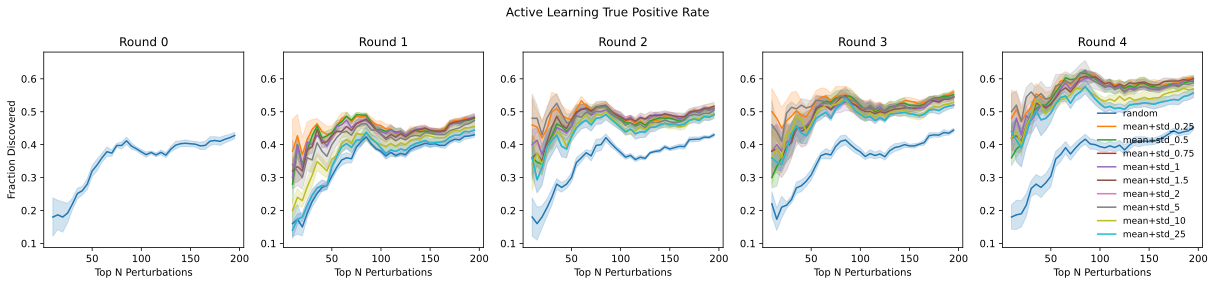

In [70]:
n_round = 5
data_stacked = results
seeds = [int(re.match(r'\d+', str(col)).group(0)) for col in results.columns if re.match(r'\d+', str(col))]
methods = ['mean+std']

data_stacked = pd.melt(results, id_vars=['Round', 'n_preds', 'Method', 'Sampling', 'Beta'], value_vars=seeds, var_name='seed', value_name='tpr')

min_ylim = np.inf
max_ylim = -np.inf
max_tpr = None

fig, axs = plt.subplots(1, n_round, figsize=((n_round*3)+2, 4))
for idx in range(n_round):
    # random data should be the same regardless of method, so choose random data from last method to plot
    data_plot = data_stacked[(data_stacked['Round'] == idx) & (data_stacked['Beta'] == betas[0]) & (data_stacked['Sampling'] == 'random')]
    # sns.lineplot(data_plot, x='n_preds', y='tpr', errorbar='se', label='random', color=method_colors['random'], ax=axs[idx])
    sns.lineplot(data_plot, x='n_preds', y='tpr', errorbar='se', label='random', ax=axs[idx])
    
    if idx > 0:
        for method in methods:
            for beta in betas:
                data_plot = data_stacked[(data_stacked['Round'] == idx) & (data_stacked['Method'] == method) & (data_stacked['Beta'] == beta) & (data_stacked['Sampling'] == 'active')]
                # sns.lineplot(data_plot, x='n_preds', y='tpr', errorbar='se', label=method, color=method_colors[method], ax=axs[idx])
                sns.lineplot(data_plot, x='n_preds', y='tpr', errorbar='se', label=f'{method}_{beta}', ax=axs[idx])

    ylims = axs[idx].get_ylim()
    if ylims[0] < min_ylim:
        min_ylim = ylims[0]
    if ylims[1] > max_ylim:
        max_ylim = ylims[1]

    axs[idx].set_title(f'Round {idx}')
    axs[idx].legend().remove()
    axs[idx].set_xlabel('Top N Perturbations')
    axs[idx].set_ylabel('')
        
axs[0].set_ylabel('Fraction Discovered')
    
for ax in axs:
    ax.set_ylim(min_ylim, max_ylim)
    if max_tpr is not None:
        ax.set_xticks([(i+1)*int(max_tpr/4) for i in range(4)])

axs[-1].legend(fontsize=9, frameon=False)

fig.suptitle(f'Active Learning True Positive Rate')
fig.tight_layout()

plt.show()

In [88]:
data_agg = (
    data_stacked
    .groupby(['Round', 'n_preds', 'Method', 'Sampling', 'Beta'])['tpr']
    .agg(['mean', 'std'])
    .reset_index()
)

In [99]:
data_agg['se'] = data_agg['std'] / np.sqrt(len(seeds))

In [100]:
data_agg.loc[(data_agg['n_preds'] == 195) & (data_agg['Sampling'] == 'active') & (data_agg['Method'] == 'mean+std') & (data_agg['Round'] == 4), ['Beta', 'mean', 'se']]

,Beta,mean,se
2720,0.25,0.602051,0.008971
2721,0.50,0.592821,0.014007
2722,1.00,0.596923,0.005280
2723,1.50,0.601026,0.008489
2724,2.00,0.556923,0.014193
2725,5.00,0.587692,0.011421
2726,10.00,0.569231,0.012973
2727,25.00,0.556923,0.014193


In [101]:
data_agg.loc[(data_agg['n_preds'] == 195) & (data_agg['Sampling'] == 'random') & (data_agg['Method'] == 'mean+std') & (data_agg['Round'] == 4) & (data_agg['Beta'] == 1), ['Beta', 'mean', 'se']]

,Beta,mean,se
2730,1.0,0.453333,0.008043


In [64]:
data_stacked[(data_stacked['Round'] == idx) & (data_stacked['Method'] == method) & (data_stacked['Beta'] == beta) & (data_stacked['Sampling'] == 'active')]

,Round,n_preds,Method,Sampling,Beta,seed,tpr


In [68]:
method

'mean+str'

In [67]:
data_stacked['Method']

0        mean+std
1        mean+std
2        mean+std
3        mean+std
4        mean+std
           ...   
13675    mean+std
13676    mean+std
13677    mean+std
13678    mean+std
13679    mean+std
Name: Method, Length: 13680, dtype: object

In [50]:
results

,850,n_preds,636,511,269,307,Round,Sampling,Method,Beta
0,0.400000,10,0.100000,0.200000,0.100000,0.100000,0,random,mean+std,0.25
1,0.333333,15,0.066667,0.200000,0.200000,0.133333,0,random,mean+std,0.25
2,0.300000,20,0.050000,0.250000,0.200000,0.100000,0,random,mean+std,0.25
3,0.240000,25,0.080000,0.240000,0.200000,0.200000,0,random,mean+std,0.25
4,0.233333,30,0.166667,0.266667,0.200000,0.233333,0,random,mean+std,0.25
...,...,...,...,...,...,...,...,...,...,...
2731,0.554286,175,0.480000,0.560000,0.548571,0.542857,4,active,mean+std,25.00
2732,0.550000,180,0.477778,0.555556,0.550000,0.544444,4,active,mean+std,25.00
2733,0.562162,185,0.491892,0.562162,0.556757,0.556757,4,active,mean+std,25.00
2734,0.573684,190,0.494737,0.563158,0.552632,0.563158,4,active,mean+std,25.00


In [4]:
method_mins = {
    'mean': True,           # since strong cell viability scores are negative, we want to minimize them
    'std': False,           # we want to pick points with maximum standard deviation
    'residual+std': False,  # and also pick points with maximum residual+std
    'mean+std': False       # we take abs(mean) before calculating this score, so we want to maximize (mean+std)
}

In [5]:
if data_source == 'norman':
    model_args = [
        {'model_type': 'both', 'd_embed': 2, 'd_pheno_hid': 64, 'p_dropout': 0.1}, 
        {'model_type': 'both', 'd_embed': 4, 'd_pheno_hid': 64, 'p_dropout': 0.1},
        {'model_type': 'both', 'd_embed': 4, 'd_pheno_hid': 64, 'p_dropout': 0.1},
        {'model_type': 'both', 'd_embed': 8, 'd_pheno_hid': 64, 'p_dropout': 0.1},
        {'model_type': 'both', 'd_embed': 16, 'd_pheno_hid': 64, 'p_dropout': 0.1}
    ]
    n_sample = [100, 200, 300, 400, 500]
elif data_source in ['simpson', 'horlbeck_jurkat', 'horlbeck_k562']:
    model_args = [
        {'model_type': 'both', 'd_embed': 2, 'd_pheno_hid': 256, 'p_dropout': 0.1}, 
        {'model_type': 'both', 'd_embed': 8, 'd_pheno_hid': 256, 'p_dropout': 0.1},
        {'model_type': 'both', 'd_embed': 8, 'd_pheno_hid': 256, 'p_dropout': 0.1},
        {'model_type': 'both', 'd_embed': 16, 'd_pheno_hid': 256, 'p_dropout': 0.1},
        {'model_type': 'both', 'd_embed': 32, 'd_pheno_hid': 256, 'p_dropout': 0.1}
    ]
    n_sample = [500, 1000, 1500, 2000, 2500]

if data_source == 'norman':
    n_epoch = 200
    batch_size = 4096
elif data_source in ['simpson', 'horlbeck_jurkat', 'horlbeck_k562']:
    n_epoch = 100
    batch_size = 4096
        
model_optimizer_settings = {'pheno_lr': 1e-2, 'embed_lr': 1e-2, 'weight_decay': 0}
test_frac = 0.3

In [6]:
data = load_naiad_data(data_file)

## Sample Beta = 0.25

In [7]:
beta = 0.25
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 0.5

In [8]:
beta = 0.5
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 0.75

In [9]:
beta = 0.5
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 1

In [10]:
beta = 1
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 1.5

In [ ]:
beta = 1.5
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 2

In [ ]:
beta = 2
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 5

In [ ]:
beta = 5
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 10

In [ ]:
beta = 10
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Sample Beta = 25

In [ ]:
beta = 25
method = 'mean+std'

time_label = datetime.now().strftime(r'%Y-%m-%d-%H-%M-%S')
result_dir = os.path.join('./results/', f'{data_source}_beta{beta}_{time_label}')
os.mkdir(result_dir)

active_learner = ActiveLearner(
    n_round = 5, 
    data = data, 
    model = NAIAD, 
    model_args = model_args,
    model_optimizer_settings = model_optimizer_settings,
    n_ensemble = 5,
    n_epoch = n_epoch,
    n_sample = n_sample, 
    test_frac = test_frac, 
    meanstd_beta = beta,
    early_stop = True,
    device = device,
    batch_size = batch_size
)

active_learner_reps = ActiveLearnerReplicates(
    n_rep = 5,
    overall_seed = 0, 
    active_learner = active_learner, 
    save_dir = result_dir, 
    save_prefix = data_source
)

active_learner_reps.set_method(method, method_mins[method])
results = active_learner_reps.run_replicates(parallel=True)
aggregated_results = active_learner_reps.aggregate_replicate_metrics(return_value=True)
active_learner_reps.save_aggregated_results(data_source)

## Compare Results

In [ ]:
active_learner_reps.plot_aggregated_results(
    metrics = ['mse', 'tpr'], 
    splits = 'overall', 
    methods = ['mean', 'std', 'residual+std'], 
    orientation = 'horizontal'
)

ValueError: cannot set a frame with no defined index and a scalar